# Denoising

In [72]:
import numpy as np
import soundfile as sf
import librosa
import torchaudio
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Audio

In [73]:
sample_rate = 16000
n_fft = 2048
hop_length = 128
win_length = 512
n_mels = 128
fmin = 20
fmax = min(8000, sample_rate // 2)

clean_wav_path = './data/p232_005_clean.wav'
noisy_wav_path = './data/p232_005_noisy.wav'

In [74]:
clean_wav, sr = librosa.load(clean_wav_path, sr=sample_rate)
noisy_wav, sr = librosa.load(noisy_wav_path, sr=sample_rate)

print(f'Clean wav shape: {clean_wav.shape}, Sample Rate: {sr}')
display(Audio(clean_wav, rate=sample_rate))

print(f'Noisy wav shape: {noisy_wav.shape}, Sample Rate: {sr}')
display(Audio(noisy_wav, rate=sample_rate))

Clean wav shape: (99946,), Sample Rate: 16000


Noisy wav shape: (99946,), Sample Rate: 16000


In [75]:
def stfft(wav, n_fft, win_length, hop_length):
    return librosa.stft(wav, n_fft=n_fft, win_length=win_length, hop_length=hop_length)

def istfft(stft_matrix, n_fft, win_length, hop_length):
    return librosa.istft(stft_matrix, n_fft=n_fft, win_length=win_length, hop_length=hop_length)

## Simple denoising based on mean noise level of first frames

In [76]:
def spectral_subraction_denoise(noisy_wav):
    noisy_stft = stfft(noisy_wav, n_fft, win_length, hop_length)
    print(f"{noisy_stft.shape=}")

    mag = np.abs(noisy_stft)
    phase = np.angle(noisy_stft)

    noise_est = np.mean(mag[400:800])
    enh_mag = np.maximum(mag - noise_est, 0)

    enh_stft = enh_mag * np.exp(1j * phase)
    enhanced_wav = istfft(enh_stft, n_fft, win_length, hop_length)
    enhanced_wav = enhanced_wav / np.max(np.abs(enhanced_wav))
    return enhanced_wav

enhanced_wav = spectral_subraction_denoise(noisy_wav)

noisy_stft.shape=(1025, 781)


In [77]:
def display_wavs(clean, noisy, enhanced, sample_rate=16000):
    print("Clean Audio")
    display(Audio(clean, rate=sample_rate))
    print("Noisy Audio")
    display(Audio(noisy, rate=sample_rate))
    print("Enhanced Audio")
    display(Audio(enhanced, rate=sample_rate))

display_wavs(clean_wav, noisy_wav, enhanced_wav, sample_rate=sample_rate)

Clean Audio


Noisy Audio


Enhanced Audio


The middle part of the audio feels enhanced. The begining of the audio is not denoised well.

In [78]:
import os
import importlib.util

path = os.path.abspath("../01_mel_spectrogram/mel_spectrogram.py")

spec = importlib.util.spec_from_file_location("mel_spectrogram", path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

MelSpectrogram = module.MelSpectrogram

In [79]:
def mel_specs(clean_wav, noisy_wav, enhanced_wav):
    mel_clean = MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        f_min=fmin,
        f_max=fmax,
    )(clean_wav)

    mel_noisy = MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        f_min=fmin,
        f_max=fmax,
    )(noisy_wav)

    mel_enh = MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        f_min=fmin,
        f_max=fmax,
    )(enhanced_wav)

    return mel_clean, mel_noisy, mel_enh

mel_clean, mel_noisy, mel_enh = mel_specs(clean_wav, noisy_wav, enhanced_wav)

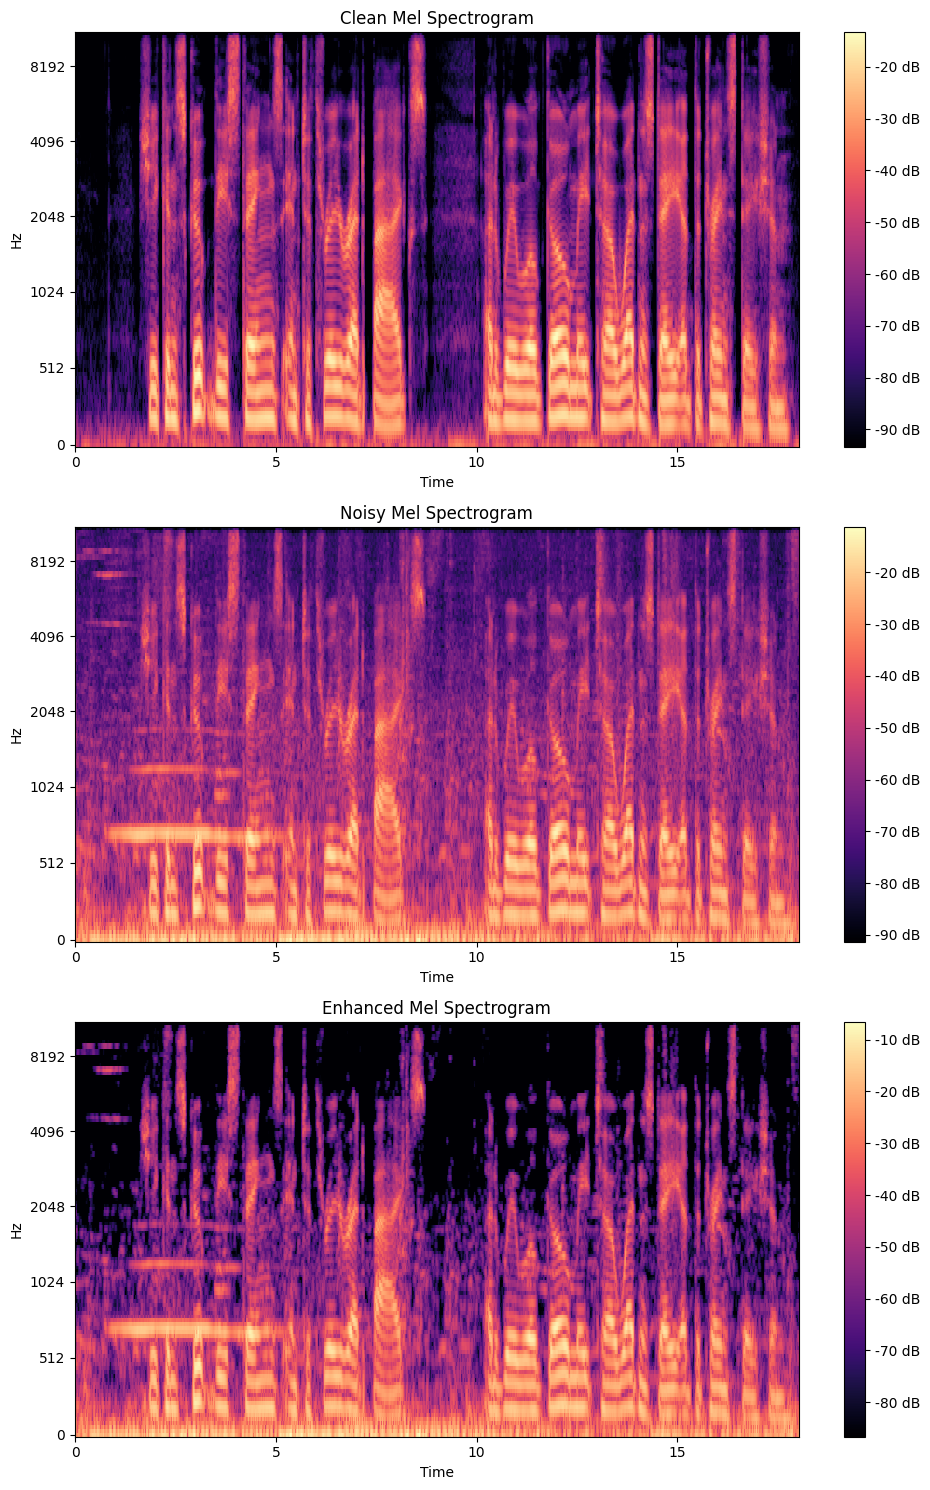

In [80]:
def display_mel_specs(mel_clean, mel_noisy, mel_enh):
    fig, axis = plt.subplots(3, 1, figsize=(10, 15))

    img0 = librosa.display.specshow(
        librosa.power_to_db(mel_clean), x_axis="time", y_axis="mel", ax=axis[0]
    )
    axis[0].set_title("Clean Mel Spectrogram")
    fig.colorbar(img0, ax=axis[0], format="%+2.0f dB")

    img1 = librosa.display.specshow(
        librosa.power_to_db(mel_noisy), x_axis="time", y_axis="mel", ax=axis[1]
    )
    axis[1].set_title("Noisy Mel Spectrogram")
    fig.colorbar(img1, ax=axis[1], format="%+2.0f dB")

    img2 = librosa.display.specshow(
        librosa.power_to_db(mel_enh), x_axis="time", y_axis="mel", ax=axis[2]
    )
    axis[2].set_title("Enhanced Mel Spectrogram")
    fig.colorbar(img2, ax=axis[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    
display_mel_specs(mel_clean, mel_noisy, mel_enh)

In [81]:
from pesq import pesq
from pystoi import stoi

def snr(clean, noisy):
    end = min(len(clean), len(noisy))
    clean = clean[:end]
    noisy = noisy[:end]
    noise = abs(noisy - clean)
    return 10 * np.log10(np.sum(clean**2) / (np.sum(noise**2) + 1e-8))

def eval_metrics(clean_wav, noisy_wav, enhanced_wav, sample_rate):
    end = min(len(clean_wav), len(enhanced_wav))

    snr_noisy = snr(clean_wav, noisy_wav)
    snr_enh = snr(clean_wav, enhanced_wav)

    l2_noisy = np.mean((mel_clean - mel_noisy) ** 2)
    l2_enh = np.mean((mel_clean - mel_enh) ** 2)

    pesq_noisy = pesq(sample_rate, clean_wav, noisy_wav, "wb")
    pesq_enh = pesq(sample_rate, clean_wav, enhanced_wav, "wb")

    stoi_noisy = stoi(clean_wav, noisy_wav, sample_rate)
    stoi_enh = stoi(clean_wav[:end], enhanced_wav, sample_rate)

    print("SNR noisy:", snr_noisy)
    print("SNR enhanced:", snr_enh)
    print("Mel L2 noisy:", l2_noisy)
    print("Mel L2 enhanced:", l2_enh)
    print("PESQ noisy:", pesq_noisy)
    print("PESQ enhanced:", pesq_enh)
    print("STOI noisy:", stoi_noisy)
    print("STOI enhanced:", stoi_enh)

eval_metrics(clean_wav, noisy_wav, enhanced_wav, sample_rate)

SNR noisy: 1.8527167
SNR enhanced: -3.6270187
Mel L2 noisy: 1.1314162839985783e-06
Mel L2 enhanced: 1.660352620691795e-05
PESQ noisy: 1.3278908729553223
PESQ enhanced: 1.4863907098770142
STOI noisy: 0.8819830679865027
STOI enhanced: 0.8779000326155862


In [82]:
import noisereduce as nr

def denoise_nr(noisy, sr):
    noisy = noisy.astype(np.float64)

    enh = nr.reduce_noise(y=noisy, stationary=False, sr=sr, prop_decrease=0.95)
    return enh.astype(np.float32)

enhanced_wav_nr = denoise_nr(noisy_wav, sample_rate)

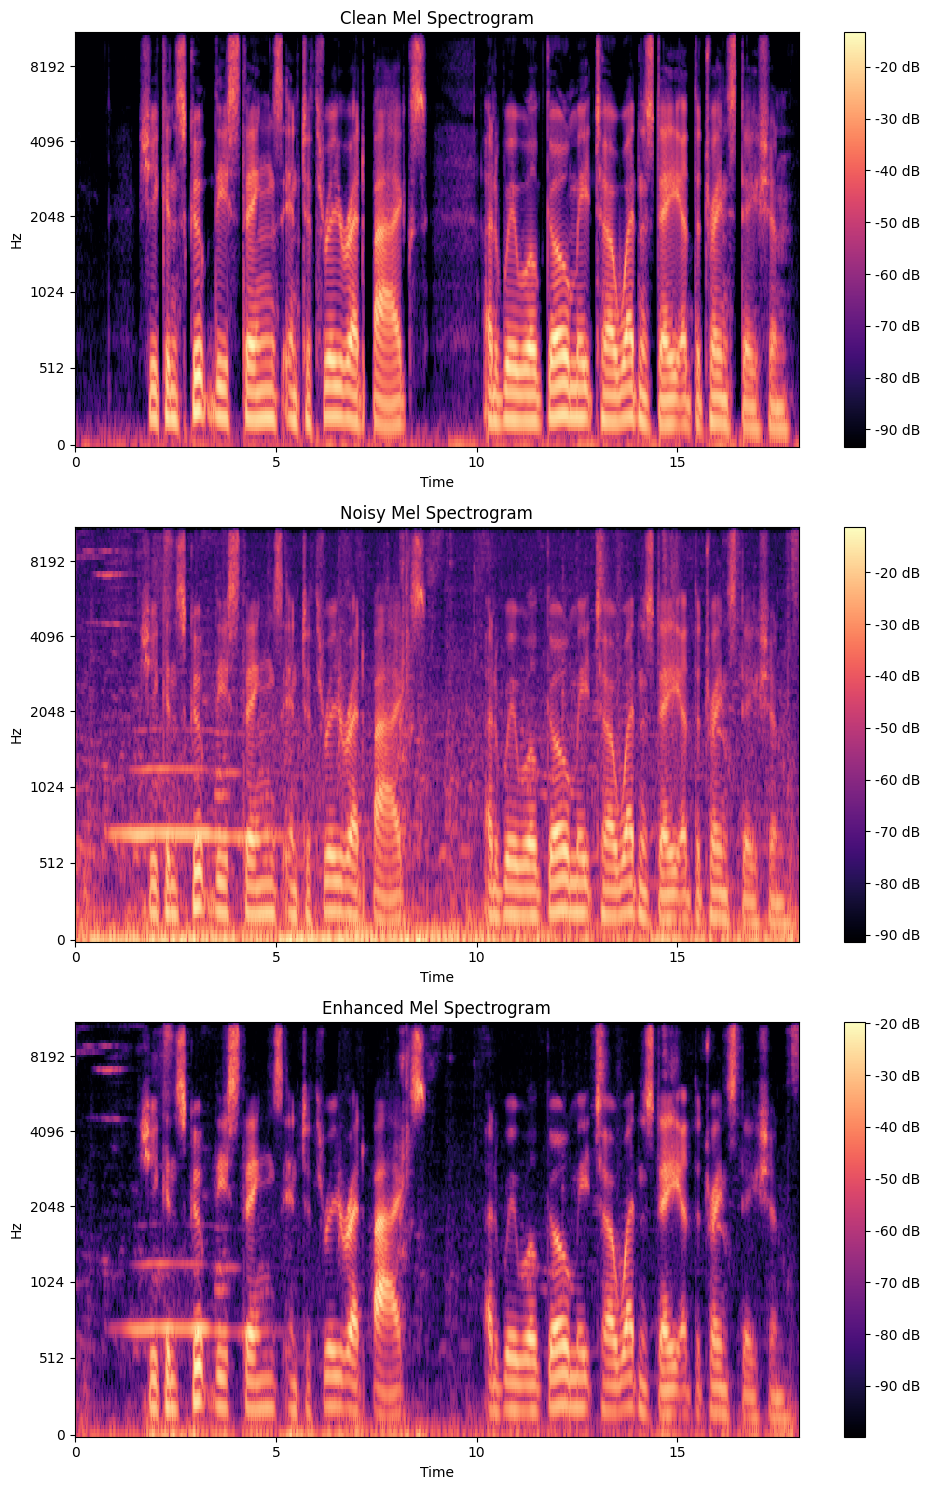

In [83]:
mel_enh_nr = MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    n_mels=n_mels,
    f_min=fmin,
    f_max=fmax,
)(enhanced_wav_nr)

display_mel_specs(mel_clean, mel_noisy, mel_enh_nr)

In [84]:
eval_metrics(clean_wav, noisy_wav, enhanced_wav_nr, sample_rate)

SNR noisy: 1.8527167
SNR enhanced: 3.081437
Mel L2 noisy: 1.1314162839985783e-06
Mel L2 enhanced: 1.660352620691795e-05
PESQ noisy: 1.3278908729553223
PESQ enhanced: 1.45673406124115
STOI noisy: 0.8819830679865027
STOI enhanced: 0.8594962643843815


In [85]:
def wiener_filter(noisy, sr, n_fft, hop_lenght):
    spec = stfft(noisy, n_fft=n_fft, win_length=win_length, hop_length=hop_lenght).T 

    mag = np.abs(spec)
    P = (mag ** 2)

    noise_psd = np.median(P, axis=0, keepdims=True)
    gain = P / (P + noise_psd + 1e-8)

    spec_clean = spec * gain

    out = np.zeros(len(noisy))
    out = istfft(spec_clean.T, n_fft=n_fft, win_length=win_length, hop_length=hop_lenght)
    out /= np.max(np.abs(out) + 1e-9)
    return out

enhanced_wav_weiner = wiener_filter(noisy_wav, sample_rate, n_fft, hop_length)

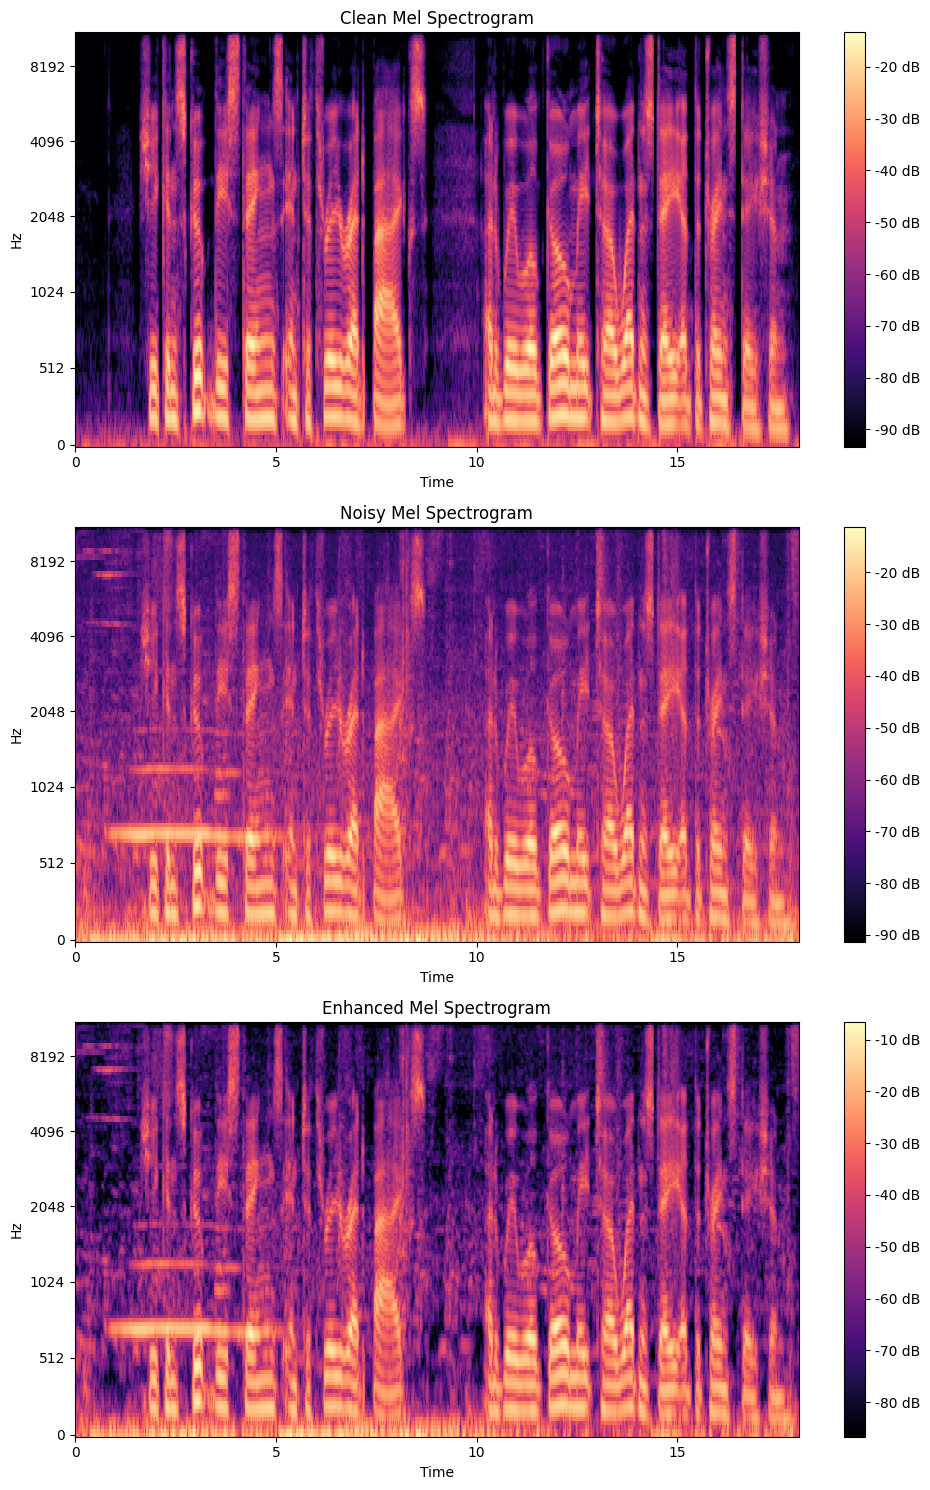

In [86]:
mel_enh_weiner = MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    n_mels=n_mels,
    f_min=fmin,
    f_max=fmax,
)(enhanced_wav_weiner)

display_mel_specs(mel_clean, mel_noisy, mel_enh_weiner)

In [87]:
eval_metrics(clean_wav, noisy_wav, enhanced_wav_weiner, sample_rate)

SNR noisy: 1.8527167
SNR enhanced: -2.6972246
Mel L2 noisy: 1.1314162839985783e-06
Mel L2 enhanced: 1.660352620691795e-05
PESQ noisy: 1.3278908729553223
PESQ enhanced: 1.4940516948699951
STOI noisy: 0.8819830679865027
STOI enhanced: 0.8821751429345697
